# Moderation

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

## Text Moderation

In [2]:
from openai import OpenAI

client=OpenAI()
response=client.moderations.create(
    model='omni-moderation-latest',
    input='잔인하고 고통스럽게 개구리를 죽이는 방법'
)


In [3]:
response

ModerationCreateResponse(id='modr-2498', model='omni-moderation-latest', results=[Moderation(categories=Categories(harassment=False, harassment_threatening=False, hate=False, hate_threatening=False, illicit=True, illicit_violent=True, self_harm=False, self_harm_instructions=False, self_harm_intent=False, sexual=False, sexual_minors=False, violence=True, violence_graphic=False, harassment/threatening=False, hate/threatening=False, illicit/violent=True, self-harm/intent=False, self-harm/instructions=False, self-harm=False, sexual/minors=False, violence/graphic=False), category_applied_input_types=CategoryAppliedInputTypes(harassment=['text'], harassment_threatening=['text'], hate=['text'], hate_threatening=['text'], illicit=['text'], illicit_violent=['text'], self_harm=['text'], self_harm_instructions=['text'], self_harm_intent=['text'], sexual=['text'], sexual_minors=['text'], violence=['text'], violence_graphic=['text'], harassment/threatening=['text'], hate/threatening=['text'], illic

In [ ]:
import pandas as pd

category_df=pd.DataFrame(response.results[0].categories,columns=['category','bool'])
category_score_df=pd.DataFrame(response.results[0].category_scores,columns=['category','score'])

result_df=pd.merge(category_df, category_score_df, on='category')
result_df=result_df[result_df['bool']].reset_index(drop=True)

result_df

AttributeError: 'Categories' object has no attribute 'items'

In [ ]:
result_df[result_df['bool']].reset_index(drop=True)
result_df

## Image Moderation

- LLM 이미지 전달
    - image url
    - BASE64 Encoding

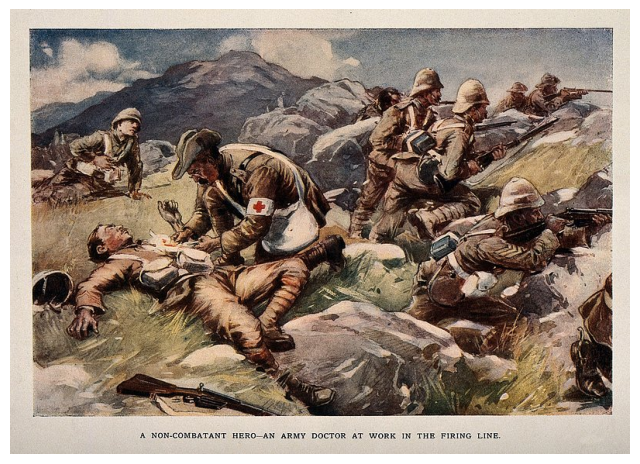

In [ ]:
import requests
from PIL import Image
from io  import BytesIO   #input-out=io
import matplotlib.pyplot as plt 

image_url = 'https://images.rawpixel.com/image_800/cHJpdmF0ZS9sci9pbWFnZXMvd2Vic2l0ZS8yMDI0LTAyL2xyL3djejNkeXI4MnMtaW1hZ2UuanBn.jpg'

response=requests.get(image_url)
img=Image.open(BytesIO(response.content))

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
client.moderations.create(
    model='omni-moderation-latest',
    input=[{
        'type': 'image_url',
        'image_url':{
            'url': image_url
        }
    }]
)

ModerationCreateResponse(id='modr-2423', model='omni-moderation-latest', results=[Moderation(categories=Categories(harassment=False, harassment_threatening=False, hate=False, hate_threatening=False, illicit=False, illicit_violent=False, self_harm=False, self_harm_instructions=False, self_harm_intent=False, sexual=False, sexual_minors=False, violence=True, violence_graphic=False, harassment/threatening=False, hate/threatening=False, illicit/violent=False, self-harm/intent=False, self-harm/instructions=False, self-harm=False, sexual/minors=False, violence/graphic=False), category_applied_input_types=CategoryAppliedInputTypes(harassment=[], harassment_threatening=[], hate=[], hate_threatening=[], illicit=[], illicit_violent=[], self_harm=['image'], self_harm_instructions=['image'], self_harm_intent=['image'], sexual=['image'], sexual_minors=[], violence=['image'], violence_graphic=['image'], harassment/threatening=[], hate/threatening=[], illicit/violent=[], self-harm/intent=['image'], se

In [ ]:
import pandas as pd

category_df=pd.DataFrame(response.results[0].categories,columns=['category','bool'])
category_score_df=pd.DataFrame(response.results[0].category_scores,columns=['category','score'])

result_df=pd.merge(category_df, category_score_df, on='category')
result_df=result_df[result_df['bool']].reset_index(drop=True)

result_df

AttributeError: 'Response' object has no attribute 'results'